In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

X_train = np.load('../data/X_train.npy')
y_train = np.load('../data/y_train.npy')
X_test  = np.load('../data/X_test.npy')
y_test  = np.load('../data/y_test.npy')

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (17731, 30, 14)
y_train shape: (17731,)
X_test shape:  (100, 30, 14)
y_test shape:  (100,)


In [2]:
# XGBoost needs a flat 2D table
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat shape:", X_train_flat.shape)  
print("X_test_flat shape: ", X_test_flat.shape)   

X_train_flat shape: (17731, 420)
X_test_flat shape:  (100, 420)


In [3]:
model = XGBRegressor(
    n_estimators   = 300,
    learning_rate  = 0.05,
    max_depth      = 6,
    subsample      = 0.8,
    random_state   = 42,
    n_jobs         = -1
)

model.fit(
    X_train_flat, y_train,
    eval_set        = [(X_test_flat, y_test)],
    verbose         = 50
)

print("Training complete.")

[0]	validation_0-rmse:40.22037
[50]	validation_0-rmse:16.89453
[100]	validation_0-rmse:15.48900
[150]	validation_0-rmse:14.88793
[200]	validation_0-rmse:14.67640
[250]	validation_0-rmse:14.46801
[299]	validation_0-rmse:14.26404
Training complete.


In [4]:
y_pred = model.predict(X_test_flat)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {rmse:.2f} cycles")

Test RMSE: 14.26 cycles


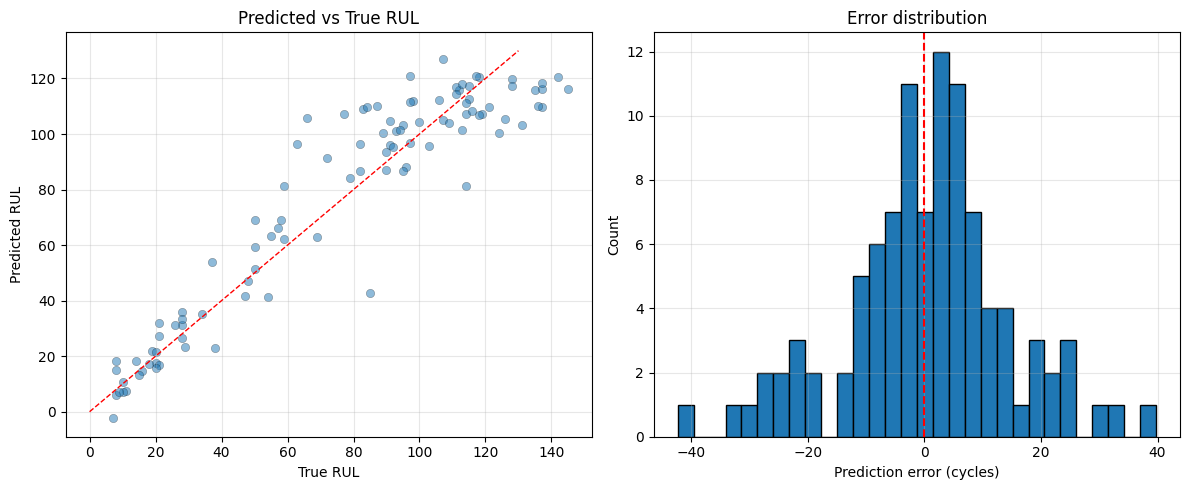

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidth=0.3)
plt.plot([0, 130], [0, 130], 'r--', linewidth=1)  # perfect prediction line
plt.xlabel('True RUL')
plt.ylabel('Predicted RUL')
plt.title('Predicted vs True RUL')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
errors = y_pred - y_test
plt.hist(errors, bins=30, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Prediction error (cycles)')
plt.ylabel('Count')
plt.title('Error distribution')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

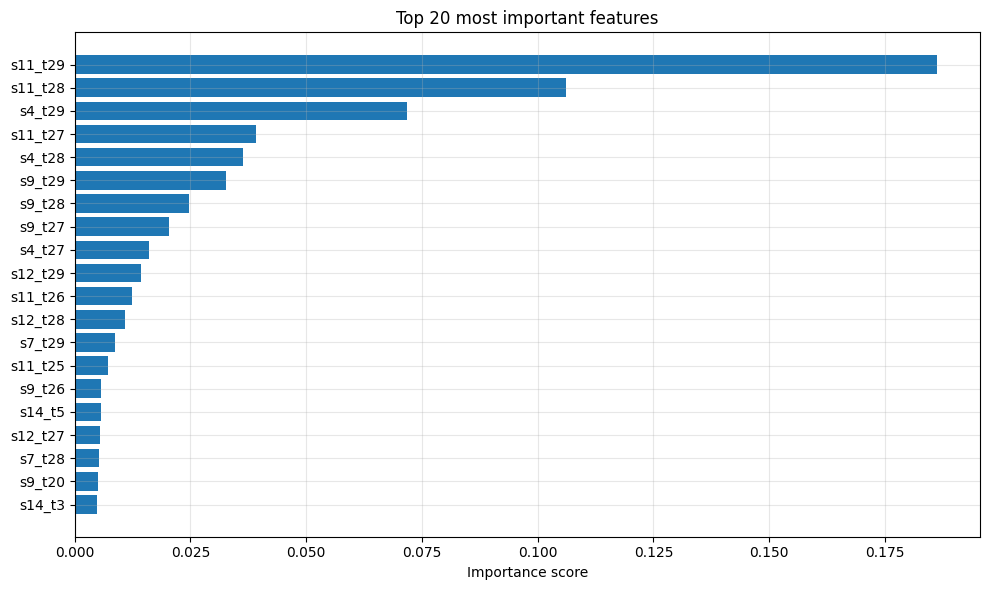

     feature  importance
412  s11_t29    0.186240
398  s11_t28    0.106028
408   s4_t29    0.071710
384  s11_t27    0.039158
394   s4_t28    0.036254
411   s9_t29    0.032607
397   s9_t28    0.024589
383   s9_t27    0.020369
380   s4_t27    0.015943
413  s12_t29    0.014243
370  s11_t26    0.012306
399  s12_t28    0.010953
409   s7_t29    0.008764
356  s11_t25    0.007122
369   s9_t26    0.005677
79    s14_t5    0.005634
385  s12_t27    0.005353
395   s7_t28    0.005231
285   s9_t20    0.005079
51    s14_t3    0.004821


In [ ]:
importances = model.feature_importances_

# Rebuild feature names to match the flattened array
USEFUL_SENSORS = ['s2','s3','s4','s7','s8','s9','s11',
                  's12','s13','s14','s15','s17','s20','s21']
WINDOW_SIZE = 30

feature_names = [f'{sensor}_t{cycle}' 
                 for cycle in range(WINDOW_SIZE) 
                 for sensor in USEFUL_SENSORS]

# Top 20 most important features
importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][::-1], 
         importance_df['importance'][::-1])
plt.xlabel('Importance score')
plt.title('Top 20 most important features')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(importance_df.to_string())

In [7]:
with open('../models/xgb_baseline.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved.")
print(f"Baseline RMSE to beat: {rmse:.2f} cycles")

Model saved.
Baseline RMSE to beat: 14.26 cycles
